In [4]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.utils.utils import save_figure

from vip_slap2_analysis.morphology import (
    load_snt_bundle,
    compute_basic_metrics,
    plot_morphology_triptych,
)

from PNW_cmap import PNW_cmap
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [5]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [148]:
save_path = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-03-17_OPhys_LabMeetingIV\figures"

In [37]:
target_mice = [
#     803496,
#     804730,804733,810196,
#     809047,803121,
    826033,
#     838410,
    834788
]

In [38]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [39]:
all_metrics = []
all_bundles = []
for asset in assets:
    try:
        reconst_path = glob.glob(os.path.join(asset.session_dir,'**','reconstruction','structure**'),recursive=True)[0]
        print(reconst_path)
        bundle = load_snt_bundle(reconst_path)
        metrics = compute_basic_metrics(bundle.tree)
        all_metrics.append(metrics)
        all_bundles.append(bundle)
    except Exception as e:
        print(asset.session_id)
        print(e)
        pass

\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34\826033_2026-02-21_09-23-34_slap2_2026-02-21_09-23-34\reconstruction\structure_volume_20260221_104501_DMD1-REFERENCE
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-23_10-45-21\826033_2026-02-23_10-45-21_slap2_2026-02-23_10-45-21\reconstruction\structure_volume_20260223_114627_DMD1-REFERENCE
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-24_14-14-45\826033_2026-02-24_14-14-45_slap2_2026-02-24_14-14-45\reconstruction\structure_volume_20260224_151043_DMD1-REFERENCE
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-25_08-49-29\826033_2026-02-25_08-49-29_slap2_2026-02-25_08-49-29\reconstruction\structure_volume_20260225_095542_DMD1-REFERENCE
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-26_12-40

In [40]:
# for i,bundle in enumerate(all_bundles):
#     try:
#         reconst_path = glob.glob(os.path.join(assets[i].session_dir,'**','reconstruction','structure**'),recursive=True)[0]
#         print(reconst_path)
#         fig, axes = plot_morphology_triptych(
#             bundle.tree,
#             smooth=True,
#             save_path_stem=None,
#         )
    
#         fig.suptitle(f'Cell01 DMD1: {assets[i].session_id}')
#         fig.tight_layout()
#         filen = 'cell_tryptic'
#         save_figure(fig,os.path.join(reconst_path,filen),formats=['.pdf','.png'],dpi=300)
#     except:
#         print(assets[i].session_id)

In [41]:
# bundle=all_bundles[-1]
# reconst_path = glob.glob(os.path.join(assets[-1].session_dir,'**','reconstruction','structure**'),recursive=True)[0]
# print(reconst_path)
# fig, axes = plot_morphology_triptych(
#     bundle.tree,
#     smooth=True,
#     save_path_stem=None,
# )

# fig.suptitle(f'Cell01 DMD1: {assets[-1].session_id}')
# fig.tight_layout()

# filen = 'cell_tryptic'
# save_figure(fig,os.path.join(Path(reconst_path).parent,filen),formats=['.pdf','.png'],dpi=300)

### Metrics analysis

In [42]:
metrics_df = pd.DataFrame(all_metrics)
metrics_df

,n_nodes,n_edges,n_roots,n_branch_points,n_tips,total_cable_length_um,mean_edge_length_um,max_edge_length_um,mean_radius_um,max_path_length_to_tip_um,...,max_strahler_order,x_min_um,y_min_um,z_min_um,x_max_um,y_max_um,z_max_um,x_span_um,y_span_um,z_span_um
0,5010.0,5009.0,1.0,31.0,36.0,2413.038528,0.481741,21.207494,0.009359,220.982657,...,4.0,98.50,4.75,0.0,216.75,147.50,150.0,118.25,142.75,150.0
1,4888.0,4887.0,1.0,21.0,29.0,2221.379541,0.454549,17.022758,0.076718,230.163425,...,4.0,72.25,31.75,0.0,277.25,195.50,150.0,205.00,163.75,150.0
2,2071.0,2070.0,1.0,12.0,17.0,1042.086451,0.503423,15.881027,0.000000,277.114928,...,3.0,120.50,29.50,3.0,267.25,120.50,150.0,146.75,91.00,147.0
3,3791.0,3790.0,1.0,24.0,28.0,1672.417741,0.441271,14.359911,0.000000,255.200379,...,4.0,82.50,31.25,0.0,195.50,191.00,121.5,113.00,159.75,121.5
4,4291.0,4290.0,1.0,16.0,22.0,1761.918033,0.410704,15.853332,0.164836,279.967596,...,3.0,81.50,39.00,0.0,247.25,170.75,133.5,165.75,131.75,133.5
5,4221.0,4220.0,1.0,13.0,18.0,1661.719134,0.393772,11.970380,0.000000,220.284459,...,3.0,50.00,2.00,0.0,274.50,153.25,111.0,224.50,151.25,111.0
6,3566.0,3565.0,1.0,20.0,26.0,1556.514989,0.436610,13.688864,0.000000,200.772572,...,4.0,90.50,1.50,0.0,250.75,189.50,100.5,160.25,188.00,100.5
7,2961.0,2960.0,1.0,22.0,35.0,1675.598455,0.566081,12.720324,0.120103,166.538525,...,4.0,61.50,64.00,0.0,162.00,195.00,150.0,100.50,131.00,150.0
8,5910.0,5909.0,1.0,30.0,43.0,2576.165021,0.435973,38.241603,0.119712,221.882301,...,4.0,51.00,1.75,0.0,232.75,180.00,121.5,181.75,178.25,121.5
9,3813.0,3812.0,1.0,16.0,21.0,1811.484712,0.475206,15.651228,0.000000,260.340512,...,4.0,59.00,2.75,0.0,231.00,168.25,150.0,172.00,165.50,150.0


In [96]:
snt = []
for asset in assets:
    try:
        path = glob.glob(os.path.join(asset.session_dir,'**','QuickMeasurements.csv'),recursive=True)[0]
        dft = pd.read_csv(path)
        snt.append(dft)
    except Exception as e:
        print(asset.session_dir)
        print(e)

In [217]:
snt_df = pd.concat(snt).reset_index(drop=True)
snt_df['session_id'] = [asset.session_id for asset in assets]
snt_df['subject_id'] = [asset.subject_id for asset in assets]
human_annotations = ['B','B','B','B','M','M','M','B','M','B','M','B','B']
snt_df['annotation'] = human_annotations

In [218]:
# snt_df = snt_df[['session_id',
#        'subject_id','annotation','No. of branch points [Single value]', 'No. of tips [Single value]',
#        'Path length (µm) [Min]', 'Path length (µm) [Max]',
#        'Path length (µm) [Mean]', 'Path length (µm) [SD]',
#        'Path length (µm) [CV]', 'Path length (µm) [Sum]',
#        'Path length (µm) [N]', 'Path order [Min]', 'Path order [Max]',
#        'Path order [Mean]', 'Path order [SD]', 'Path order [CV]',
#        'Path order [Sum]', 'Path order [N]', 'Sholl: Decay [Single value]',
#        'Sholl: Degree of Polynomial fit [Single value]',
#        'Sholl: Kurtosis [Single value]', 'Sholl: Max [Single value]',
#        'Sholl: Max (fitted) [Single value]',
#        'Sholl: Max (fitted) radius (µm) [Single value]',
#        'Sholl: Mean [Single value]', 'Sholl: No. maxima [Single value]',
#        'Sholl: No. secondary maxima [Single value]',
#        'Sholl: Ramification index [Single value]',
#        'Sholl: Skeweness [Single value]', 'Sholl: Sum [Single value]',
#        'No. of compartments', 'Sholl: Degree of Polynomial fit',
#        'Sholl: Max (fitted)', 'Sholl: Max (fitted) radius (µm)',]]

In [219]:
snt_df.keys()

Index(['-', 'Cable length (µm) [Single value]', 'SWC Type(s)',
       'Branch length (µm) [MIN]', 'Branch length (µm) [MAX]',
       'Branch length (µm) [MEAN]', 'Branch length (µm) [STD_DEV]',
       'Branch length (µm) [N]', 'No. of branch points [Single value]',
       'No. of tips [Single value]', 'No. of branches [Single value]',
       'No. of primary branches [Single value]',
       'No. of terminal branches [Single value]',
       'Path mean radius (µm) [MIN]', 'Path mean radius (µm) [MAX]',
       'Path mean radius (µm) [MEAN]', 'Path mean radius (µm) [STD_DEV]',
       'Path mean radius (µm) [N]', 'Path spine/varicosity density [MIN]',
       'Path spine/varicosity density [MAX]',
       'Path spine/varicosity density [MEAN]',
       'Path spine/varicosity density [STD_DEV]',
       'Path spine/varicosity density [N]',
       'Horton-Strahler root number [Single value]', 'Path order [MIN]',
       'Path order [MAX]', 'Path order [MEAN]', 'Path order [STD_DEV]',
       'Path o

In [220]:
cl,cmap,cp = PNW_cmap.get_PNW_cmap('Sailboat',n_colors=2)

<IPython.core.display.Javascript object>


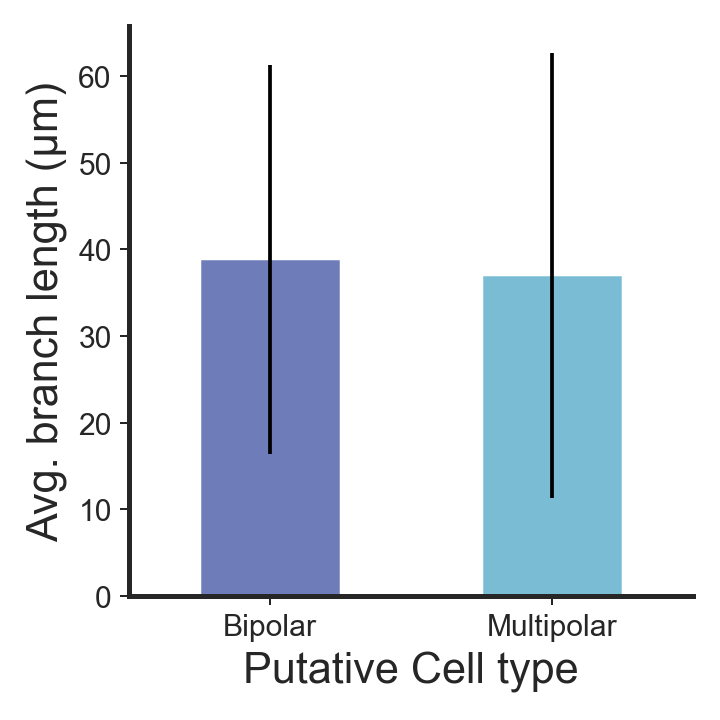

In [233]:
fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

b_df = snt_df[snt_df['annotation']=='B']
m_df = snt_df[snt_df['annotation']=='M']

metric = 'No. of branches [Single value]'
#'Path order [MEAN]' 
#'Branch length (µm) [MEAN]'
#'No. of primary branches [Single value]'
#'No. of branches [Single value]'
#'Cable length (µm) [Single value]'


b_mean = np.mean(b_df[metric])
b_std = np.std(b_df[metric],ddof=1)

m_mean = np.mean(m_df[metric])
m_std = np.std(m_df[metric],ddof=1)

ax.bar([1,2],[b_mean,m_mean],width=0.5,color=cl)
ax.errorbar([1],[b_mean],[b_std],color='k')
ax.errorbar([2],[m_mean],[m_std],color='k')

ax.set_xticks([1,2])
ax.set_xticklabels(['Bipolar','Multipolar'])
ax.set_ylabel('Avg. branch length (\u03BCm)')
ax.set_xlabel('Putative Cell type')
ax.set_xlim(0.5,2.5)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()
filen = '2026-03-31_BranchLength'
# save_figure(fig,os.path.join(save_path,filen),formats=['.pdf','.png'],dpi=300)

### Sholl analysis

In [222]:
sholl = []
for asset in assets:
    try:
        path = glob.glob(os.path.join(asset.session_dir,'**','Sholl_Table**.csv'),recursive=True)[0]
        dft = pd.read_csv(path)
        sholl.append(dft)
    except Exception as e:
        print(asset.session_dir)
        print(e)

In [223]:
from scipy.interpolate import interp1d

def average_sholl_curves(
    sholls,
    value_col="Length",
    radius_col="Radius",
    r_grid=None,
    fill_value=np.nan,
):
    """
    Interpolate Sholl curves from multiple neurons onto a common radius grid
    and return mean/sem summaries.

    Parameters
    ----------
    sholl_paths : list of path-like
        Paths to per-neuron Sholl CSVs.
    value_col : str
        Column to average, e.g. 'Length' or 'Inters.'.
    radius_col : str
        Radius column name.
    r_grid : array-like or None
        Shared radius grid in microns. If None, inferred from all files.
    fill_value : float
        Value outside each neuron's sampled radius range. Usually np.nan.

    Returns
    -------
    summary_df : pd.DataFrame
        Columns: Radius, mean, sem, median, n
    interp_df : pd.DataFrame
        Rows = neurons, columns = shared radius grid
    """
    curves = []
    all_radii = []

    for df in sholls:
        # keep only valid points
        sub = df[[radius_col, value_col]].dropna().copy()
        sub = sub.sort_values(radius_col)

        r = sub[radius_col].to_numpy(dtype=float)
        y = sub[value_col].to_numpy(dtype=float)

        # remove duplicate radii if present
        uniq_r, uniq_idx = np.unique(r, return_index=True)
        r = uniq_r
        y = y[uniq_idx]

        curves.append((Path(path).stem, r, y))
        all_radii.append(r)

    if r_grid is None:
        rmax = max(r.max() for r in all_radii)
        r_grid = np.arange(0, np.ceil(rmax) + 1, 2.0)  # 2 µm spacing

    interp_rows = []
    names = []

    for name, r, y in curves:
        f = interp1d(
            r,
            y,
            kind="linear",
            bounds_error=False,
            fill_value=fill_value,
        )
        y_interp = f(r_grid)
        interp_rows.append(y_interp)
        names.append(name)

    interp_df = pd.DataFrame(interp_rows, index=names, columns=r_grid)

    summary_df = pd.DataFrame({
        "Radius": r_grid,
        "mean": interp_df.mean(axis=0, skipna=True).to_numpy(),
        "sem": interp_df.sem(axis=0, skipna=True).to_numpy(),
        "median": interp_df.median(axis=0, skipna=True).to_numpy(),
        "n": interp_df.notna().sum(axis=0).to_numpy(),
    })

    return summary_df, interp_df

In [224]:
b_sholls = [s for i,s in enumerate(sholl) if human_annotations[i]=='B']
m_sholls = [s for i,s in enumerate(sholl) if human_annotations[i]=='M']

b_avg,b_interp = average_sholl_curves(b_sholls)
m_avg,m_interp = average_sholl_curves(m_sholls)

<IPython.core.display.Javascript object>


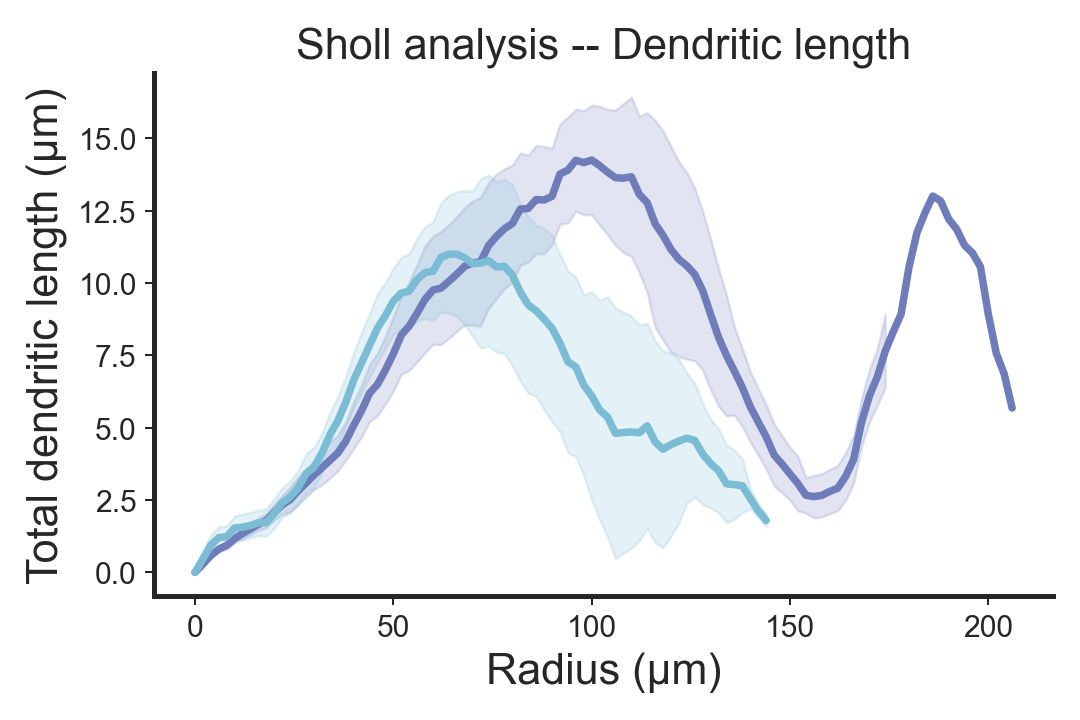

In [225]:
color_map = {'B':cl[0],'M':cl[1]}

fig,ax=plt.subplots(figsize=(6,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

# for i,s in enumerate(sholl):
#     ax.plot(s['Radius'],pd.DataFrame(s['Length']).rolling(100,min_periods=1).mean(),color=color_map[human_annotations[i]],alpha=0.5)

b_mean = pd.DataFrame(b_avg['median']).rolling(10,min_periods=1).mean()
b_std = pd.DataFrame(b_avg['sem']).rolling(10,min_periods=1).mean()
m_mean = pd.DataFrame(m_avg['median']).rolling(10,min_periods=1).mean()
m_std = pd.DataFrame(m_avg['sem']).rolling(10,min_periods=1).mean()

ax.plot(b_avg['Radius'],b_mean,color=cl[0],lw=3)
ax.fill_between(b_avg['Radius'],np.ravel([b_mean.values+b_std.values]), np.ravel([b_mean.values-b_std.values]),
                color=cl[0],zorder=0,alpha=0.2)

ax.plot(m_avg['Radius'],m_mean,color=cl[1],lw=3)
ax.fill_between(m_avg['Radius'],np.ravel([m_mean.values+m_std.values]),np.ravel([m_mean.values-m_std.values]),
                color=cl[1],zorder=0,alpha=0.2)

ax.set_xlabel('Radius (\u03BCm)')
ax.set_ylabel('Total dendritic length (\u03BCm)')
ax.set_title('Sholl analysis -- Dendritic length')
fig.tight_layout()
filen = '2026-03-31_Sholl'
save_figure(fig,os.path.join(save_path,filen),formats=['.pdf','.png'],dpi=300)